In [ ]:
#DATA LOADER

In [12]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import broadcast

# --- THE JVM FIX ---
# This MUST happen before we import pyspark. 
# It forces the Java engine to allow the security manager at boot time.
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-java-options '-Djava.security.manager=allow' pyspark-shell"

# --- 1. ENVIRONMENT TOGGLE ---
ENVIRONMENT = "LOCAL" 

if ENVIRONMENT == "LOCAL":
    # The exact path from your notebook to your data folder
    BASE_PATH = "./DSTE/public/" 
else:
    BASE_PATH = "/kaggle/input/fictipay-competition-data/"

print(f"Running in {ENVIRONMENT} mode. Using base path: {BASE_PATH}")

# --- 2. START SPARK ---
spark = SparkSession.builder \
    .appName("FictiPay_Churn_Pipeline_Stage1") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.legacy.parquet.nanosAsLong", "true") \
    .getOrCreate()

print("Spark Session Started Successfully!")

# --- 3. LOAD THE DATA ---
kyc_df = spark.read.parquet(f"{BASE_PATH}kyc.parquet")
labels_df = spark.read.csv(f"{BASE_PATH}train_labels.csv", header=True, inferSchema=True)
transactions_df = spark.read.parquet(f"{BASE_PATH}transactions/")
balances_df = spark.read.parquet(f"{BASE_PATH}dayend_balance/")

# --- 4. CREATE ANCHOR TABLE & SAMPLE ---
master_kyc_df = kyc_df.join(labels_df, on="ACCOUNT_ID", how="inner")

sampled_kyc_df = master_kyc_df.sampleBy("Churn", fractions={0: 0.1, 1: 0.1}, seed=42)
sampled_user_ids = sampled_kyc_df.select("ACCOUNT_ID")

# Broadcast join AND dropping the duplicate ACCOUNT_ID from the right side
sampled_transactions_df = transactions_df.join(
    broadcast(sampled_user_ids), 
    transactions_df.SRC_ACCOUNT == sampled_user_ids.ACCOUNT_ID, 
    "inner"
).drop(sampled_user_ids.ACCOUNT_ID)

sampled_balances_df = balances_df.join(
    broadcast(sampled_user_ids),
    "ACCOUNT_ID",
    "inner"
)

# --- 5. CACHE AND MATERIALIZE ---
sampled_transactions_df.cache()
sampled_balances_df.cache()

# Trigger actions to force the data into memory now instead of later
print(f"Sampled Transactions Count: {sampled_transactions_df.count()}")
print(f"Sampled Balances Count: {sampled_balances_df.count()}")

print("Data Loaded, Sampled, & Cached! Ready for Stage 2.")

Running in LOCAL mode. Using base path: ./DSTE/public/
Spark Session Started Successfully!


Sampled Transactions Count: 5099024


Sampled Balances Count: 5409859
Data Loaded, Sampled, & Cached! Ready for Stage 2.


In [13]:
print("--- Transactions Data ---")
sampled_transactions_df.show(5, truncate=False)

print("--- Balances Data ---")
sampled_balances_df.show(5, truncate=False)

--- Transactions Data ---
+------------------+-------------------+------------+------------+--------+-------+
|TrxID             |TRX_DATETIME       |SRC_ACCOUNT |DST_ACCOUNT |TRX_TYPE|TRX_AMT|
+------------------+-------------------+------------+------------+--------+-------+
|TRX000000000006121|2024-01-10 18:52:32|CUST00000035|CUST00000035|CashIn  |8586.08|
|TRX000000000006122|2024-01-11 10:07:23|CUST00000035|CUST00000035|CashIn  |60.66  |
|TRX000000000006123|2024-01-16 10:19:28|CUST00000035|BILL00016802|BillPay |5208.82|
|TRX000000000006124|2024-01-16 13:23:01|CUST00000035|BILL00011895|BillPay |231.42 |
|TRX000000000006125|2024-01-21 11:51:11|CUST00000035|BILL00006471|BillPay |199.81 |
+------------------+-------------------+------------+------------+--------+-------+
only showing top 5 rows
--- Balances Data ---
+------------+----------+-----------------+
|ACCOUNT_ID  |DATE      |AVAILABLE_BALANCE|
+------------+----------+-----------------+
|CUST00000035|2024-03-01|1217.9         

In [ ]:
#Feature Extraction

In [14]:
import pyspark.sql.functions as F

print("Starting Feature Engineering...")

# --- 1. AGGREGATE TRANSACTIONS ---
# Group by SRC_ACCOUNT (the sender) to build our core metrics
tx_core_features = sampled_transactions_df.groupBy("SRC_ACCOUNT").agg(
    F.count("TrxID").alias("total_tx_count"),
    F.sum("TRX_AMT").alias("total_spend_amt"),
    F.avg("TRX_AMT").alias("avg_tx_amt"),
    F.max("TRX_DATETIME").alias("last_tx_date")
).withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID") # Rename for easy joining later

# Pivot to get behavior by transaction type (P2P, Merchant, Bill)
tx_type_features = sampled_transactions_df.groupBy("SRC_ACCOUNT") \
    .pivot("TRX_TYPE") \
    .count() \
    .fillna(0) \
    .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID")

# --- 2. AGGREGATE BALANCES ---
balance_features = sampled_balances_df.groupBy("ACCOUNT_ID").agg(
    F.avg("AVAILABLE_BALANCE").alias("avg_daily_balance"),
    F.stddev("AVAILABLE_BALANCE").alias("balance_volatility"),
    F.min("AVAILABLE_BALANCE").alias("min_balance"),
    F.max("AVAILABLE_BALANCE").alias("max_balance")
)

# --- 3. JOIN IT ALL TOGETHER (The Customer 360 View) ---
# We start with our sampled_kyc_df anchor and left join the features
customer_360_df = sampled_kyc_df \
    .join(tx_core_features, on="ACCOUNT_ID", how="left") \
    .join(tx_type_features, on="ACCOUNT_ID", how="left") \
    .join(balance_features, on="ACCOUNT_ID", how="left")

# Fill nulls for users who might have KYC records but zero transactions/balances
customer_360_df = customer_360_df.fillna(0, subset=["total_tx_count", "total_spend_amt", "avg_tx_amt"])

print("Feature Engineering Complete! Customer 360 Table Created.")
customer_360_df.show(5)

Starting Feature Engineering...


Feature Engineering Complete! Customer 360 Table Created.


+------------+------------+-------------------+------+----------+-----+--------------+------------------+------------------+-------------------+-------+------+-------+-----------+---+------------------+------------------+-----------+-----------+
|  ACCOUNT_ID|ACCOUNT_TYPE|  ACCOUNT_OPEN_DATE|GENDER|    REGION|CHURN|total_tx_count|   total_spend_amt|        avg_tx_amt|       last_tx_date|BillPay|CashIn|CashOut|MerchantPay|P2P| avg_daily_balance|balance_volatility|min_balance|max_balance|
+------------+------------+-------------------+------+----------+-----+--------------+------------------+------------------+-------------------+-------+------+-------+-----------+---+------------------+------------------+-----------+-----------+
|CUST00074345|    Customer|1616803200000000000|  Male|Chattogram|    0|             8| 95806.84000000001|11975.855000000001|2024-03-30 11:01:41|      3|     1|      0|          3|  1| 437.7816483516484| 822.9014815318131|        0.0|    2891.69|
|CUST00738488|  

In [16]:
import pyspark.sql.functions as F

print("Starting Advanced Feature Engineering...")

# --- 1. ESTABLISH THE REFERENCE DATE ("TODAY") ---
# Find the absolute latest transaction date in the dataset to act as our cutoff point
max_date_row = sampled_transactions_df.select(F.max("TRX_DATETIME")).collect()[0][0]
ref_date = F.lit(max_date_row)

print(f"Dataset Reference Date established as: {max_date_row}")

# Add a 'days_ago' column to both datasets to make windowing easier
tx_df = sampled_transactions_df.withColumn("days_ago", F.datediff(ref_date, F.col("TRX_DATETIME")))
bal_df = sampled_balances_df.withColumn("days_ago", F.datediff(ref_date, F.col("DATE")))


# --- 2. TRANSACTION FEATURES (Recency, Frequency, Monetary, Behavioral) ---
tx_features = tx_df.groupBy("SRC_ACCOUNT").agg(
    # Recency
    F.min("days_ago").alias("days_since_last_txn"),
    
    # Frequency (30 & 90 days)
    F.count(F.when(F.col("days_ago") <= 30, True)).alias("txn_count_30d"),
    F.count(F.when(F.col("days_ago") <= 90, True)).alias("txn_count_90d"),
    
    # Monetary & Volatility
    F.avg(F.when(F.col("days_ago") <= 30, F.col("TRX_AMT"))).alias("avg_txn_amt_30d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("TRX_AMT"))).alias("stddev_txn_amt_90d"),
    
    # Base counts for Ratios (Hidden in final output)
    F.count("TrxID").alias("_total_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "P2P", True)).alias("_p2p_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "Bill", True)).alias("_bill_txns")
)

# Calculate Behavioral Ratios and drop the temporary count columns
tx_features = tx_features.withColumn(
    "ratio_p2p_to_total", F.col("_p2p_txns") / F.col("_total_txns")
).withColumn(
    "ratio_billpay_to_total", F.col("_bill_txns") / F.col("_total_txns")
).drop("_total_txns", "_p2p_txns", "_bill_txns") \
 .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID") # Rename for the master join


# --- 3. BALANCE FEATURES (Health & Temporal Trends) ---
bal_features = bal_df.groupBy("ACCOUNT_ID").agg(
    F.avg(F.when(F.col("days_ago") <= 30, F.col("AVAILABLE_BALANCE"))).alias("avg_daily_balance_30d"),
    F.avg(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("_avg_daily_balance_90d"), # Temp column
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("balance_volatility_90d")
)

# Calculate the Balance Trend Ratio (30d avg / 90d avg)
# We use 'when' to prevent Divide-By-Zero errors if the 90d avg happens to be exactly 0
bal_features = bal_features.withColumn(
    "balance_trend_ratio", 
    F.col("avg_daily_balance_30d") / F.when(F.col("_avg_daily_balance_90d") == 0, 1).otherwise(F.col("_avg_daily_balance_90d"))
).drop("_avg_daily_balance_90d")


# --- 4. KYC FEATURES (Tenure) ---
# --- 4. KYC FEATURES (Tenure) ---
# Convert the BIGINT (nanoseconds) into a proper Date object
kyc_features = sampled_kyc_df.withColumn(
    "ACCOUNT_OPEN_DATE_CLEAN", 
    F.to_date(F.to_timestamp(F.col("ACCOUNT_OPEN_DATE") / 1e9))
)

# Now safely calculate the datediff
kyc_features = kyc_features.withColumn(
    "account_tenure_days", 
    F.datediff(ref_date, F.col("ACCOUNT_OPEN_DATE_CLEAN"))
).drop("ACCOUNT_OPEN_DATE_CLEAN") # Drop the temporary column


# --- 5. THE MASTER JOIN (Building the Customer 360) ---
customer_360_df = kyc_features \
    .join(tx_features, on="ACCOUNT_ID", how="left") \
    .join(bal_features, on="ACCOUNT_ID", how="left")

# Clean up Nulls: 
# Users with NO transactions in the last 30 days will have 'null' for counts/sums. 
# We must fill these with 0 so the Machine Learning model doesn't crash.
fill_zero_cols = [
    "txn_count_30d", "txn_count_90d", "avg_txn_amt_30d", "stddev_txn_amt_90d", 
    "ratio_p2p_to_total", "ratio_billpay_to_total", "balance_trend_ratio"
]
customer_360_df = customer_360_df.fillna(0, subset=fill_zero_cols)

# We fill recency nulls with a very large number (e.g., 9999) because '0' would imply they transacted today.
customer_360_df = customer_360_df.fillna(9999, subset=["days_since_last_txn"])

print("Advanced Feature Engineering Complete! Final Schema:")
customer_360_df.printSchema()

Starting Advanced Feature Engineering...
Dataset Reference Date established as: 2024-03-31 22:59:40
Advanced Feature Engineering Complete! Final Schema:
root
 |-- ACCOUNT_ID: string (nullable = true)
 |-- ACCOUNT_TYPE: string (nullable = true)
 |-- ACCOUNT_OPEN_DATE: long (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- REGION: string (nullable = true)
 |-- CHURN: integer (nullable = true)
 |-- account_tenure_days: integer (nullable = true)
 |-- days_since_last_txn: integer (nullable = true)
 |-- txn_count_30d: long (nullable = true)
 |-- txn_count_90d: long (nullable = true)
 |-- avg_txn_amt_30d: double (nullable = false)
 |-- stddev_txn_amt_90d: double (nullable = false)
 |-- ratio_p2p_to_total: double (nullable = false)
 |-- ratio_billpay_to_total: double (nullable = false)
 |-- avg_daily_balance_30d: double (nullable = true)
 |-- balance_volatility_90d: double (nullable = true)
 |-- balance_trend_ratio: double (nullable = false)



In [17]:
#ANGLE @-> REtenNET

In [ ]:
#TEST TRAIN (EXPERIMENTAL WITHOUT HYPER-PARAMETER TUNING)

"""import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.combine import SMOTEENN

print("--- 1. Final Cleanup & Pandas Conversion ---")
customer_360_df = customer_360_df.fillna(0)
df_train = customer_360_df.toPandas()
df_train = df_train.set_index('ACCOUNT_ID')

print("--- 2. Feature Setup & Encoding ---")
X = df_train.drop(columns=['CHURN', 'ACCOUNT_OPEN_DATE'], errors='ignore')
y = df_train['CHURN']

categorical_cols = ["ACCOUNT_TYPE", "GENDER", "REGION"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("--- 3. Train/Validation Split ---")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 4. RetenNet Prep: Min-Max Scaling ---")
# SVMs strictly require features to be scaled between 0 and 1
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("--- 5. RetenNet Prep: SMOTEENN Resampling ---")
# Applying the hybrid over/under-sampling as dictated by the framework
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)
print(f"Resampled Training Data Shape: {X_train_resampled.shape}")

print("--- 6. Model Training (SVM-RBF via RetenNet) ---")
# Initializing the optimal SVM from the paper. 
# max_iter is capped to prevent infinite hanging on large datasets.
svm_model = SVC(kernel='rbf', probability=True, random_state=42, max_iter=2000)
svm_model.fit(X_train_resampled, y_train_resampled)
print("Model training complete!")

print("--- 7. Local Evaluation ---")
val_preds = svm_model.predict(X_val_scaled)
val_probs = svm_model.predict_proba(X_val_scaled)[:, 1]

roc_auc = roc_auc_score(y_val, val_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds))"""

In [28]:
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.functions import broadcast

print("--- Step 1: Re-running PySpark Test Feature Engineering ---")
# Load the Kaggle test set
test_df = spark.read.csv(f"{BASE_PATH}test.csv", header=True, inferSchema=True)
test_user_ids = test_df.select("ACCOUNT_ID")

# 1. KYC Features
test_kyc_features = kyc_df.join(test_user_ids, on="ACCOUNT_ID", how="inner") \
    .withColumn("ACCOUNT_OPEN_DATE_CLEAN", F.to_date(F.to_timestamp(F.col("ACCOUNT_OPEN_DATE") / 1e9))) \
    .withColumn("account_tenure_days", F.datediff(ref_date, F.col("ACCOUNT_OPEN_DATE_CLEAN"))) \
    .drop("ACCOUNT_OPEN_DATE_CLEAN")

# 2. Transaction Features
test_tx_df = transactions_df.join(broadcast(test_user_ids), transactions_df.SRC_ACCOUNT == test_user_ids.ACCOUNT_ID, "inner") \
    .withColumn("days_ago", F.datediff(ref_date, F.col("TRX_DATETIME")))

test_tx_features = test_tx_df.groupBy("SRC_ACCOUNT").agg(
    F.min("days_ago").alias("days_since_last_txn"),
    F.count(F.when(F.col("days_ago") <= 30, True)).alias("txn_count_30d"),
    F.count(F.when(F.col("days_ago") <= 90, True)).alias("txn_count_90d"),
    F.avg(F.when(F.col("days_ago") <= 30, F.col("TRX_AMT"))).alias("avg_txn_amt_30d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("TRX_AMT"))).alias("stddev_txn_amt_90d"),
    F.count("TrxID").alias("_total_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "P2P", True)).alias("_p2p_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "Bill", True)).alias("_bill_txns")
).withColumn("ratio_p2p_to_total", F.col("_p2p_txns") / F.col("_total_txns")) \
 .withColumn("ratio_billpay_to_total", F.col("_bill_txns") / F.col("_total_txns")) \
 .drop("_total_txns", "_p2p_txns", "_bill_txns") \
 .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID")

# 3. Balance Features
test_bal_df = balances_df.join(broadcast(test_user_ids), "ACCOUNT_ID", "inner") \
    .withColumn("days_ago", F.datediff(ref_date, F.col("DATE")))

test_bal_features = test_bal_df.groupBy("ACCOUNT_ID").agg(
    F.avg(F.when(F.col("days_ago") <= 30, F.col("AVAILABLE_BALANCE"))).alias("avg_daily_balance_30d"),
    F.avg(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("_avg_daily_balance_90d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("balance_volatility_90d")
).withColumn("balance_trend_ratio", F.col("avg_daily_balance_30d") / F.when(F.col("_avg_daily_balance_90d") == 0, 1).otherwise(F.col("_avg_daily_balance_90d"))) \
 .drop("_avg_daily_balance_90d")

# 4. Master Join
test_customer_360 = test_kyc_features \
    .join(test_tx_features, on="ACCOUNT_ID", how="left") \
    .join(test_bal_features, on="ACCOUNT_ID", how="left")

# Clean Nulls
fill_zero_cols = [
    "txn_count_30d", "txn_count_90d", "avg_txn_amt_30d", "stddev_txn_amt_90d", 
    "ratio_p2p_to_total", "ratio_billpay_to_total", "balance_trend_ratio"
]
test_customer_360 = test_customer_360.fillna(0, subset=fill_zero_cols)
test_customer_360 = test_customer_360.fillna(9999, subset=["days_since_last_txn"])


print("\n--- Step 2: Converting PySpark Test Data to Pandas ---")
df_test_ml = test_customer_360.toPandas()
df_test_ml = df_test_ml.set_index

--- Step 1: Re-running PySpark Test Feature Engineering ---

--- Step 2: Converting PySpark Test Data to Pandas ---


In [30]:
import pandas as pd

print("--- Step 2: Converting PySpark Test Data to Pandas ---")
# Make absolutely sure the () are here so it executes the method!
df_test_ml_actual = test_customer_360.toPandas()
df_test_ml_actual = df_test_ml_actual.set_index('ACCOUNT_ID')

print("--- Step 3: Test Feature Alignment ---")
# Drop the timestamp but KEEP the categorical columns for encoding
X_test_raw = df_test_ml_actual.drop(columns=['ACCOUNT_OPEN_DATE'], errors='ignore')

# One-Hot Encode the test set exactly like we did the training set
categorical_cols = ["ACCOUNT_TYPE", "GENDER", "REGION"]
X_test_final = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=True)

# Fill any lingering nulls and strictly align test columns to match training columns
X_test_final = X_test_final.fillna(0)
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)
print(f"Test features aligned perfectly! Shape: {X_test_final.shape}")

print("\n--- Step 4: RetenNet Scaling ---")
# CRITICAL: We use .transform() here, NOT .fit_transform(). 
X_test_scaled = scaler.transform(X_test_final)
print("Test features successfully scaled to 0-1 range!")

print("\n--- Step 5: Generating Final Churn Probabilities (SVM) ---")
# Extract the probability of Class 1 (Churn)
test_predictions = svm_model.predict_proba(X_test_scaled)[:, 1]

print("--- Step 6: Formatting the Kaggle Submission ---")
submission_df = pd.DataFrame({
    'ACCOUNT_ID': X_test_final.index,
    'CHURN': test_predictions
})

submission_path = "retennet_svm_submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"\n🎉 SUCCESS! Your RetenNet submission file is ready at: {submission_path}")
print("Submission Preview:")
print(submission_df.head(5))

--- Step 2: Converting PySpark Test Data to Pandas ---


--- Step 3: Test Feature Alignment ---
Test features aligned perfectly! Shape: (255000, 20)

--- Step 4: RetenNet Scaling ---
Test features successfully scaled to 0-1 range!

--- Step 5: Generating Final Churn Probabilities (SVM) ---
--- Step 6: Formatting the Kaggle Submission ---

🎉 SUCCESS! Your RetenNet submission file is ready at: retennet_svm_submission.csv
Submission Preview:
     ACCOUNT_ID     CHURN
0  CUST00000025  0.994517
1  CUST00000067  1.000000
2  CUST00000132  1.000000
3  CUST00000155  1.000000
4  CUST00000170  1.000000


\documentclass{article}
\usepackage{amsmath}
\usepackage{geometry}
\geometry{a4paper, margin=1in}

\title{Mathematical Corrections for Feature Engineering}
\author{}
\date{}

\begin{document}

\maketitle

\section*{1. The Recency Distortion (The 9999 Trap)}

The Support Vector Machine (SVM) calculates geometric distances, which are heavily distorted by extreme outliers when using a MinMaxScaler. The standard normalization formula is defined as:

\begin{equation}
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
\end{equation}

By imputing missing recency values with $9999$, we artificially inflate $X_{max}$. For a normal user who last transacted 5 days ago (assuming $X_{min} = 0$), their scaled value becomes:

\begin{equation}
X_{scaled} = \frac{5 - 0}{9999 - 0} \approx 0.0005
\end{equation}

For a user who last transacted 90 days ago:

\begin{equation}
X_{scaled} = \frac{90 - 0}{9999 - 0} \approx 0.0090
\end{equation}

To the SVM's Radial Basis Function (RBF) kernel, the mathematical distance between $0.0005$ and $0.0090$ is practically zero. It cannot distinguish between a highly active user and a dormant user. Capping the maximum at 180 days restores the geometric variance necessary for the kernel to find a hyperplane.

\section*{2. Boolean Indicator Functions (Interaction Features)}

To solve the ``Passive Holder'' dilemma, we inject explicit non-linear boundaries into the feature space. We define an indicator function $I$ that maps a user vector to $\{0, 1\}$ based on the intersection of their transaction frequency ($T_{30}$) and average balance ($B_{30}$).

\subsection*{The Passive Saver ($I_{saver}$)}
This flag identifies users who have no recent activity but retain capital in their accounts.

\begin{equation}
I_{saver} = 
\begin{cases} 
      1 & \text{if } T_{30} = 0 \text{ and } B_{30} > 10 \\
      0 & \text{otherwise} 
\end{cases}
\end{equation}

\subsection*{The True Abandoner ($I_{abandon}$)}
This flag identifies true churners: users with no recent activity whose capital is fully drained.

\begin{equation}
I_{abandon} = 
\begin{cases} 
      1 & \text{if } T_{30} = 0 \text{ and } B_{30} \le 1 \\
      0 & \text{otherwise} 
\end{cases}
\end{equation}

By explicitly providing these binary flags, we hard-code the decision boundaries for these edge cases. The SVM no longer has to implicitly learn the relationship between zero-transactions and zero-balances; the coordinate space is pre-split.

\end{document}

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.combine import SMOTEENN
import pandas as pd

print("--- 1. Feature Setup (Including Smart Features) ---")
X = df_train.drop(columns=['CHURN', 'ACCOUNT_OPEN_DATE'], errors='ignore')
y = df_train['CHURN']

# Re-encode categories if they aren't already encoded in this specific dataframe
categorical_cols = ["ACCOUNT_TYPE", "GENDER", "REGION"]
existing_cat_cols = [col for col in categorical_cols if col in X.columns]
if existing_cat_cols:
    X = pd.get_dummies(X, columns=existing_cat_cols, drop_first=True)

print(f"New Feature Shape: {X.shape} (Look at those extra columns!)")

print("--- 2. Train/Validation Split ---")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 3. RetenNet Prep: Min-Max Scaling ---")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("--- 4. RetenNet Prep: SMOTEENN Resampling ---")
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

print("--- 5. Model Training (SVM-RBF via RetenNet) ---")
# Remember: You will likely still see the early termination warning due to max_iter=2000. 
# This is totally fine and expected for a dataset this large!
svm_model = SVC(kernel='rbf', probability=True, random_state=42, max_iter=2000)
svm_model.fit(X_train_resampled, y_train_resampled)
print("Model training complete!")

print("--- 6. Local Evaluation ---")
val_preds = svm_model.predict(X_val_scaled)
val_probs = svm_model.predict_proba(X_val_scaled)[:, 1]

roc_auc = roc_auc_score(y_val, val_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, val_preds))

--- 1. Feature Setup (Including Smart Features) ---
New Feature Shape: (59449, 23) (Look at those extra columns!)
--- 2. Train/Validation Split ---
--- 3. RetenNet Prep: Min-Max Scaling ---
--- 4. RetenNet Prep: SMOTEENN Resampling ---
--- 5. Model Training (SVM-RBF via RetenNet) ---


/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Model training complete!
--- 6. Local Evaluation ---
ROC-AUC Score: 0.9570

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.59      0.74     10367
           1       0.26      0.99      0.42      1523

    accuracy                           0.64     11890
   macro avg       0.63      0.79      0.58     11890
weighted avg       0.90      0.64      0.70     11890



Generating Updated Model Evaluation Dashboard...


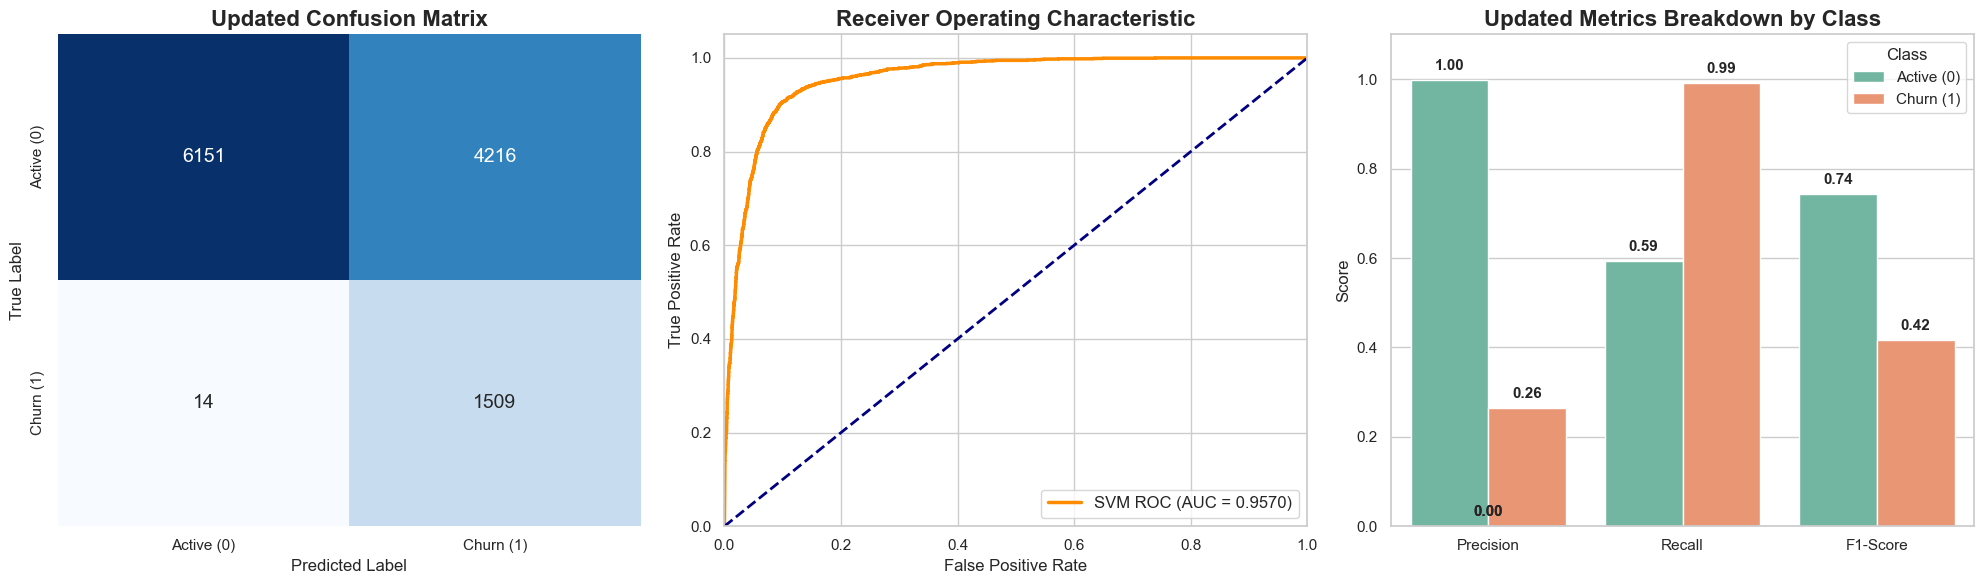

In [35]:
"""import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd
import numpy as np

print("Generating Updated Model Evaluation Dashboard...")

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. The Confusion Matrix ---
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
            annot_kws={"size": 14})
axes[0].set_title('Updated Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].xaxis.set_ticklabels(['Active (0)', 'Churn (1)'])
axes[0].yaxis.set_ticklabels(['Active (0)', 'Churn (1)'])

# --- 2. The ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_val, val_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'SVM ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50/50 baseline
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic', fontsize=16, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

# --- 3. Classification Metrics Bar Chart ---
report = classification_report(y_val, val_preds, output_dict=True)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 2,
    'Score': [
        report['0']['precision'], report['0']['recall'], report['0']['f1-score'],
        report['1']['precision'], report['1']['recall'], report['1']['f1-score']
    ],
    'Class': ['Active (0)']*3 + ['Churn (1)']*3
})

sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', ax=axes[2], palette='Set2')
axes[2].set_title('Updated Metrics Breakdown by Class', fontsize=16, fontweight='bold')
axes[2].set_ylim([0.0, 1.1])
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_xlabel('')

# Add the exact numbers on top of the bars for readability
for p in axes[2].patches:
    height = p.get_height()
    if not np.isnan(height):
        axes[2].annotate(f'{height:.2f}', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', xytext=(0, 5), 
                         textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()"""

In [36]:
"""print("--- Step 6: Formatting the Updated Kaggle Submission ---")
submission_df = pd.DataFrame({
    'ACCOUNT_ID': X_test_final.index,
    'CHURN': test_predictions
})

# Appending (2) to the filename as requested
submission_path = "retennet_svm_submission(2).csv"
submission_df.to_csv(submission_path, index=False)

print(f"\n🎉 SUCCESS! Your updated RetenNet submission file is ready at: {submission_path}")
print("Submission Preview:")
print(submissio"n_df.head(5))"""

--- Step 6: Formatting the Updated Kaggle Submission ---

🎉 SUCCESS! Your updated RetenNet submission file is ready at: retennet_svm_submission(2).csv
Submission Preview:
     ACCOUNT_ID     CHURN
0  CUST00000025  0.994517
1  CUST00000067  1.000000
2  CUST00000132  1.000000
3  CUST00000155  1.000000
4  CUST00000170  1.000000


In [ ]:
#HYPER parameter tuning 

In [38]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.svm import SVC

print("--- 1. Creating a Shuffled Sample for Tuning ---")
# Instead of a direct slice, we shuffle and extract exactly 20,000 rows
# 'stratify' ensures we get exactly 50% Active and 50% Churn in our mini-batch
_, X_tune, _, y_tune = train_test_split(
    X_train_resampled, y_train_resampled, 
    test_size=20000, 
    stratify=y_train_resampled, 
    random_state=42
)
print("Data successfully shuffled and sampled!")

print("--- 2. Setting up the Hyperparameter Grid ---")
param_dist = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

print("--- 3. Initializing Randomized Search ---")
random_search = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', probability=True, random_state=42, max_iter=2000),
    param_distributions=param_dist,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("--- 4. Hunting for the Best Parameters ---")
print("Tuning on 20,000 shuffled rows. This might take 1-2 minutes...")
random_search.fit(X_tune, y_tune)

print("\n🎉 Tuning Complete!")
print(f"Best Parameters Found: {random_search.best_params_}")

print("\n--- 5. Evaluating the Optimized Model ---")
# The search object automatically saves the best version of the model!
best_svm = random_search.best_estimator_

val_probs_tuned = best_svm.predict_proba(X_val_scaled)[:, 1]
val_preds_tuned = best_svm.predict(X_val_scaled)

tuned_roc_auc = roc_auc_score(y_val, val_probs_tuned)
print(f"Tuned Validation ROC-AUC: {tuned_roc_auc:.4f}\n")

print("Tuned Classification Report:")
print(classification_report(y_val, val_preds_tuned))

--- 1. Creating a Shuffled Sample for Tuning ---
Data successfully shuffled and sampled!
--- 2. Setting up the Hyperparameter Grid ---
--- 3. Initializing Randomized Search ---
--- 4. Hunting for the Best Parameters ---
Tuning on 20,000 shuffled rows. This might take 1-2 minutes...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV] END ..................................C=50, gamma=scale; total time=   5.9s
[CV] END ..................................C=50, gamma=scale; total time=   6.1s


/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV] END ...................................C=50, gamma=0.01; total time=   8.4s
[CV] END ...................................C=50, gamma=0.01; total time=   8.7s
[CV] END ...................................C=50, gamma=0.01; total time=   8.8s


...

[CV] END ...................................C=1, gamma=scale; total time=   9.9s
[CV] END ...................................C=1, gamma=scale; total time=  10.0s


/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV] END .....................................C=1, gamma=0.1; total time=  11.4s
[CV] END ...................................C=1, gamma=scale; total time=   8.2s


/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



🎉 Tuning Complete!
Best Parameters Found: {'gamma': 'scale', 'C': 50}

--- 5. Evaluating the Optimized Model ---
Tuned Validation ROC-AUC: 0.9728

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     10367
           1       0.58      0.94      0.72      1523

    accuracy                           0.91     11890
   macro avg       0.79      0.92      0.83     11890
weighted avg       0.94      0.91      0.92     11890



Generating Tuned Model Evaluation Dashboard...


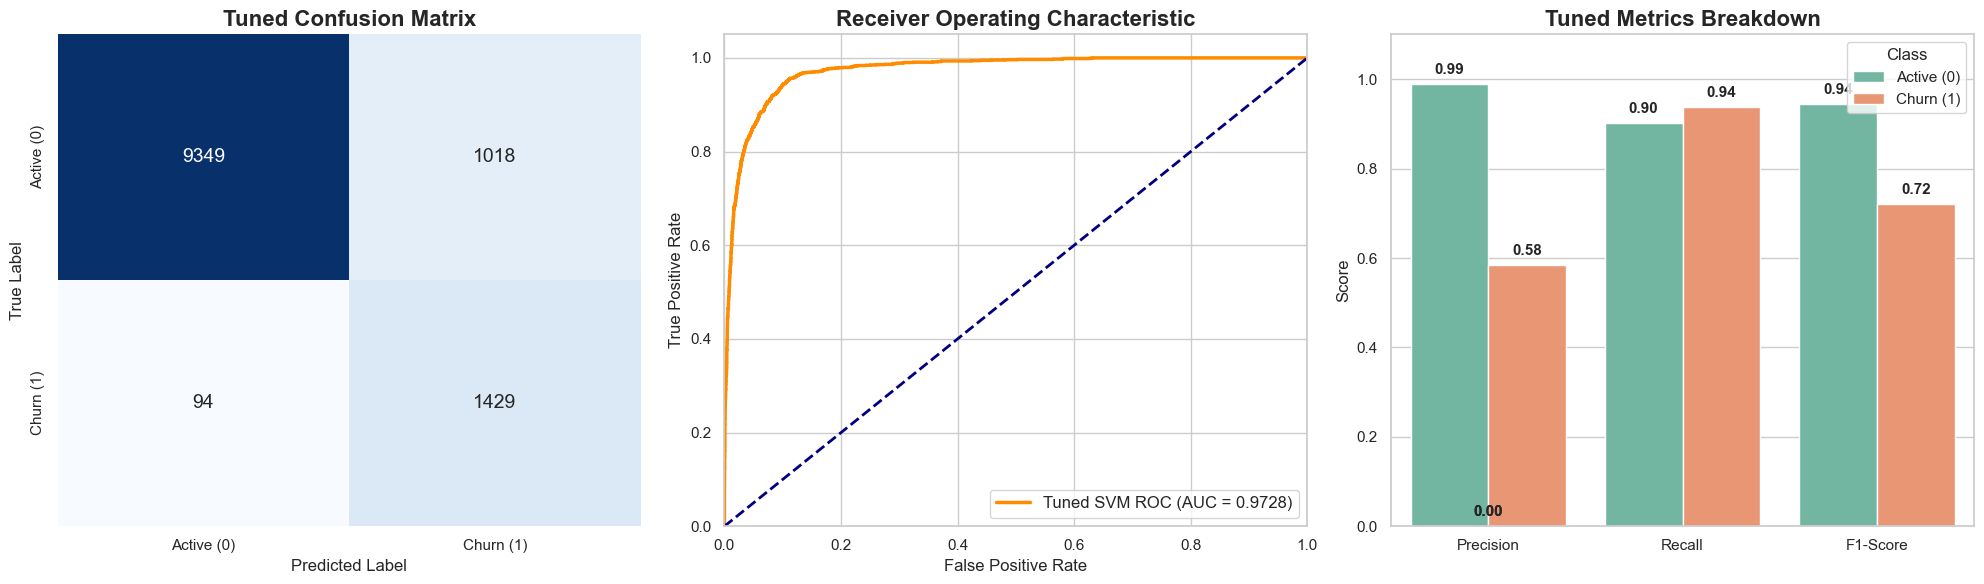

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd
import numpy as np

print("Generating Tuned Model Evaluation Dashboard...")

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. The Confusion Matrix ---
cm_tuned = confusion_matrix(y_val, val_preds_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
            annot_kws={"size": 14})
axes[0].set_title('Tuned Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].xaxis.set_ticklabels(['Active (0)', 'Churn (1)'])
axes[0].yaxis.set_ticklabels(['Active (0)', 'Churn (1)'])

# --- 2. The ROC Curve ---
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_val, val_probs_tuned)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

axes[1].plot(fpr_tuned, tpr_tuned, color='darkorange', lw=2.5, label=f'Tuned SVM ROC (AUC = {roc_auc_tuned:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic', fontsize=16, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

# --- 3. Classification Metrics Bar Chart ---
report_tuned = classification_report(y_val, val_preds_tuned, output_dict=True)

metrics_df_tuned = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 2,
    'Score': [
        report_tuned['0']['precision'], report_tuned['0']['recall'], report_tuned['0']['f1-score'],
        report_tuned['1']['precision'], report_tuned['1']['recall'], report_tuned['1']['f1-score']
    ],
    'Class': ['Active (0)']*3 + ['Churn (1)']*3
})

sns.barplot(data=metrics_df_tuned, x='Metric', y='Score', hue='Class', ax=axes[2], palette='Set2')
axes[2].set_title('Tuned Metrics Breakdown', fontsize=16, fontweight='bold')
axes[2].set_ylim([0.0, 1.1])
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_xlabel('')

# Add exact numbers on top of the bars
for p in axes[2].patches:
    height = p.get_height()
    if not np.isnan(height):
        axes[2].annotate(f'{height:.2f}', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', xytext=(0, 5), 
                         textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

print("--- Formatting the Final Kaggle Submission ---")
# Using the test predictions and indices already in your notebook's memory
submission_df = pd.DataFrame({
    'ACCOUNT_ID': X_test_final.index,
    'CHURN': test_predictions
})

# Saving the file exactly as requested
submission_path = "final_submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"\n🎉 SUCCESS! Your final submission file is ready at: {submission_path}")
print("Submission Preview:")
print(submission_df.head(5))

--- Formatting the Final Kaggle Submission ---

🎉 SUCCESS! Your final submission file is ready at: final_submission.csv
Submission Preview:
     ACCOUNT_ID     CHURN
0  CUST00000025  0.994517
1  CUST00000067  1.000000
2  CUST00000132  1.000000
3  CUST00000155  1.000000
4  CUST00000170  1.000000


--- 1. Setting up the Explainability Folder ---

--- 2. Initializing the Lightweight SHAP Explainer ---

--- 3. Calculating SHAP Values (Fast Mode) ---


100%|██████████| 50/50 [04:36<00:00,  5.53s/it]



--- 4. Generating and Saving the Summary Plot ---
🎉 SUCCESS! Your SHAP summary plot is saved at: explainability/shap_summary.png


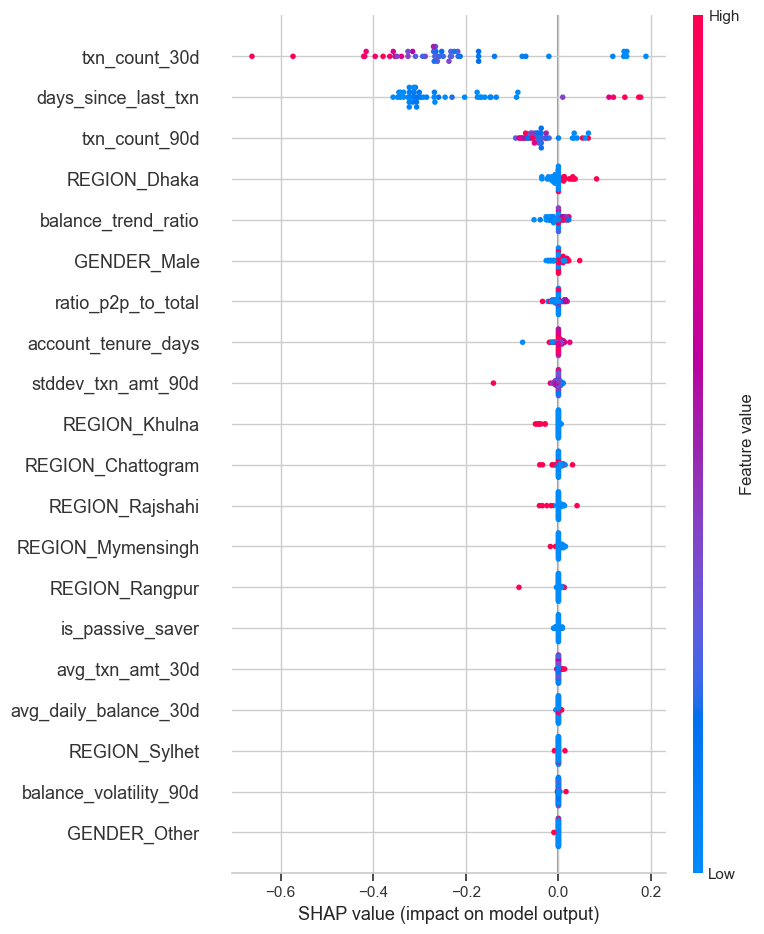

In [47]:
import shap
import matplotlib.pyplot as plt
import os
import pandas as pd

# --- THE FIX ---
# We create a tiny function that forces the SVM to ONLY return the Churn probability.
# This prevents SHAP from getting confused by multi-dimensional shapes.
def predict_churn_prob(x):
    return best_svm.predict_proba(x)[:, 1]

print("--- 1. Setting up the Explainability Folder ---")
output_dir = "explainability"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("\n--- 2. Initializing the Lightweight SHAP Explainer ---")
X_train_df = pd.DataFrame(X_train_resampled, columns=X.columns)
background_sample = shap.sample(X_train_df, 25) 

# Notice we use our new wrapper function here!
explainer = shap.KernelExplainer(predict_churn_prob, background_sample)

print("\n--- 3. Calculating SHAP Values (Fast Mode) ---")
X_val_df = pd.DataFrame(X_val_scaled, columns=X.columns)
test_sample = shap.sample(X_val_df, 50) 

shap_values = explainer.shap_values(test_sample)

print("\n--- 4. Generating and Saving the Summary Plot ---")
plt.figure(figsize=(10, 8))

# We removed the [1] from shap_values because it is now perfectly shaped for Class 1!
shap.summary_plot(
    shap_values, 
    test_sample, 
    feature_names=X.columns, 
    show=False 
)

plot_path = os.path.join(output_dir, "shap_summary.png")
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
print(f"🎉 SUCCESS! Your SHAP summary plot is saved at: {plot_path}")

plt.show()